In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from math import pi
D=1 #diffusion coefficient 
t=2 #time 
x=3 #position 
P_t=(1/(4*pi*D*t)**(1/2))*np.exp(-x**2/(4*D*t))
#input vector

q0=np.array([[3],[2]])

#first layer
W1=np.array([[0.01,0.02,0.03],[0.04,0.05,0.06]]) #weight 1
b1=np.array([[0.07],[0.08],[0.09]]) #bais 1
Z1= np.dot(W1.T,q0)+b1 # pre-activation output of layer 1
#second layer

W2=np.array([[0.05],[0.1],[0.15]]) #weight 2
b2=np.array([[0.05]]) #bais 2

#ReLU activation function
q1=np.maximum(0,Z1) 
Z2=np.dot(W2.T,q1)+b2 # pre-activation output of layer 2

#Applying softplus activation function
P=np.log(1+np.exp(Z2)) # Prediction output
print(P_t,q0,W1,b1,Z1,W2,b2,q1,Z2,P)


0.06475879783294587
[[3]
 [2]]
[[0.01 0.02 0.03]
 [0.04 0.05 0.06]] [[0.07]
 [0.08]
 [0.09]] [[0.18]
 [0.24]
 [0.3 ]]
[[0.05]
 [0.1 ]
 [0.15]] [[0.05]] [[0.18]
 [0.24]
 [0.3 ]] [[0.128]]
[[0.75919378]]


In [10]:
#Loss function(Mean Squared Error)
L=(1/2)*(P-P_t)**2 #P_t is the theoretical distribution
print(L)

[[0.24111997]]


In [11]:
#Backpropagation (computing derivatives)
dL_dP= P-P_t # derivative of loss wrt prediction
#layer 2
dP_dZ2=(np.exp(Z2))/(1+np.exp(Z2)) #derivative of the prediction wrt pre-activation function
delta2=dL_dP*dP_dZ2 #error term for layer 2
dL_dW2=q1*delta2 #derivative of the loss wrt weight 2
dL_db2=delta2 #derivative of the loss wrt bias 2
#layer 1
dL_dq1=W2*delta2 #derivative of the loss wrt activation output of layer 1(ReLU)
dL_dZ1=dL_dq1*(Z1>0) #derivative of the loss wrt pre-activation function of layer 1 (ReLU)
delta1=dL_dZ1 #error term for layer 1
dL_dW1=np.outer(q0,delta1) #derivative of the loss wrt weight 1
dL_db1=delta1 #derivative of the loss wrt to bias 1
print(dL_dP,dP_dZ2,delta2,dL_dW2,dL_db2,dL_dq1,dL_dZ1,delta1,dL_dW1,dL_db1)

[[0.69443499]] [[0.53195638]] [[0.36940912]] [[0.06649364]
 [0.08865819]
 [0.11082274]] [[0.36940912]] [[0.01847046]
 [0.03694091]
 [0.05541137]] [[0.01847046]
 [0.03694091]
 [0.05541137]] [[0.01847046]
 [0.03694091]
 [0.05541137]] [[0.05541137 0.11082274 0.1662341 ]
 [0.03694091 0.07388182 0.11082274]] [[0.01847046]
 [0.03694091]
 [0.05541137]]


In [12]:
#Gradient descent update 
lr=0.01 
W1=W1-lr*np.outer(q0,delta1.T) #updates weight 1
W2=W2-lr*(dL_dW2) #updates weight 2 
b1=b1-lr*delta1 #updates bias 1 
b2=b2-lr*delta2 #updates bias 2 
print(W1,W2,b1,b2)

[[0.00944589 0.01889177 0.02833766]
 [0.03963059 0.04926118 0.05889177]] [[0.04933506]
 [0.09911342]
 [0.14889177]] [[0.0698153 ]
 [0.07963059]
 [0.08944589]] [[0.04630591]]


In [13]:
# Generate N training samples
N=1000

x_samples=np.random.uniform(0.1,3.0,N)   # x values
t_samples=np.random.uniform(0.1,3.0,N)   # t values (avoid t=0, undefined)

# True P values for each sample
P_theo=(1/np.sqrt(4*np.pi*D*t_samples))*np.exp(-x_samples**2/(4*D*t_samples))

In [14]:
epochs=5000

print_at = [0, 500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500]

for epoch in range(epochs):
    T_loss=0
    for i in range(N):
        q0=np.array([[x_samples[i]],[t_samples[i]]]) #input vector for the current sample
        P_theo=(1/np.sqrt(4*np.pi*D*t_samples[i]))*np.exp(-x_samples[i]**2/(4*D*t_samples[i])) 
        # Forward pass
        Z1= np.dot(W1.T,q0)+b1
        q1=np.maximum(0,Z1) 
        Z2=np.dot(W2.T,q1)+b2
        P=np.log(1+np.exp(Z2)) # Prediction output
        
        # Loss calculation
        L=(1/2)*(P-P_theo)**2 # mean error square
        T_loss+=L
        # Backpropagation (computing derivatives)
        dL_dP= P-P_theo 
        dP_dZ2=(np.exp(Z2))/(1+np.exp(Z2)) #derivative of the prediction wrt pre-activation function
        delta2=dL_dP*dP_dZ2 #error term for layer 2
        dL_dW2=q1*delta2 #derivative of the loss wrt weight 2
        dL_db2=delta2 #derivative of the loss wrt bias 2
        
        dL_dq1=W2*delta2 #derivative of the loss wrt activation output of layer 1(ReLU)
        dL_dZ1=dL_dq1*(Z1>0) #derivative of the loss wrt pre-activation function of layer 1 (ReLU)
        delta1=dL_dZ1 #error term for layer 1
        dL_dW1=np.dot(q0,delta1.T) #derivative of the loss wrt weight 
        dL_db1=delta1 #derivative of the loss wrt to bias 1
        
        # Gradient descent update 
        W1=W1-lr*(dL_dW1) #updates weight 1
        W2=W2-lr*(dL_dW2) #updates weight 2 
        b1=b1-lr*delta1 #updates bias 1 
        b2=b2-lr*delta2 #updates bias 2 
    L_ave=T_loss/N
    if epoch in print_at:
        print(f"Epoch {epoch:4d} | Loss: {float(L_ave):.6f} | P: {float(P):.6f} | P_analytical: {float(P_theo):.6f}")    
        

C:\Users\Reneiloe Nyathela\AppData\Local\Temp\ipykernel_11048\2881394771.py:39: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"Epoch {epoch:4d} | Loss: {float(L_ave):.6f} | P: {float(P):.6f} | P_analytical: {float(P_theo):.6f}")


Epoch    0 | Loss: 0.051349 | P: 0.309075 | P_analytical: 0.426727
Epoch  500 | Loss: 0.001271 | P: 0.332656 | P_analytical: 0.426727
Epoch 1000 | Loss: 0.001271 | P: 0.332652 | P_analytical: 0.426727
Epoch 1500 | Loss: 0.001237 | P: 0.335416 | P_analytical: 0.426727
Epoch 2000 | Loss: 0.000659 | P: 0.402932 | P_analytical: 0.426727
Epoch 2500 | Loss: 0.000641 | P: 0.408488 | P_analytical: 0.426727
Epoch 3000 | Loss: 0.000641 | P: 0.408523 | P_analytical: 0.426727
Epoch 3500 | Loss: 0.000641 | P: 0.408524 | P_analytical: 0.426727
Epoch 4000 | Loss: 0.000641 | P: 0.408523 | P_analytical: 0.426727
Epoch 4500 | Loss: 0.000641 | P: 0.408521 | P_analytical: 0.426727


In [37]:
# Test points

x_test=np.array([-2.5,-2,-1.5,-1,-0.5, 0, 0.5, 1.0, 1.5, 2, 2.5])
t_test=np.array([-2.5,-2,-1.5,-1,-0.5, 0, 0.5, 1.0, 1.5, 2, 2.5])

print(f"{'x':>6} {'t':>6} {'P_analytical':>12} {'P':>12} {'Error':>12} {'% Error':>10}")
print("-" * 60)

for x_i, t_i in zip(x_test, t_test):

    # Analytical solution
    P_analytical=(1/np.sqrt(4*np.pi*D*t_i))*np.exp(-x_i**2/(4*D*t_i))

    # Network prediction
    q0=np.array([x_i, t_i])
    Z1=np.dot(W1.T, q0) + b1
    q1=np.maximum(0, Z1)
    Z2=np.dot(W2.T, q1) + b2
    P=np.log(1 + np.exp(Z2))

    error=abs(P - P_analytical)
    pct_error=(error/P_analytical)*100
    print(type(P), type(P_analytical), type(error)) 
    print(f"{x_i:>6.2f} {t_i:>6.2f} {P_analytical:>12.6f} {float(P[0][0]):>12.6f} {float(error[0][0]):>12.6f} {float(pct_error[0][0]):>9.2f}%")

    

     x      t P_analytical            P        Error    % Error
------------------------------------------------------------
<class 'numpy.ndarray'> <class 'numpy.float64'> <class 'numpy.ndarray'>
 -2.50  -2.50          nan     0.264848          nan       nan%
<class 'numpy.ndarray'> <class 'numpy.float64'> <class 'numpy.ndarray'>
 -2.00  -2.00          nan     0.264848          nan       nan%
<class 'numpy.ndarray'> <class 'numpy.float64'> <class 'numpy.ndarray'>
 -1.50  -1.50          nan     0.301095          nan       nan%
<class 'numpy.ndarray'> <class 'numpy.float64'> <class 'numpy.ndarray'>
 -1.00  -1.00          nan     0.447478          nan       nan%
<class 'numpy.ndarray'> <class 'numpy.float64'> <class 'numpy.ndarray'>
 -0.50  -0.50          nan     0.645294          nan       nan%
<class 'numpy.ndarray'> <class 'numpy.float64'> <class 'numpy.ndarray'>
  0.00   0.00          nan     0.833912          nan       nan%
<class 'numpy.ndarray'> <class 'numpy.float64'> <class 'num

C:\Users\Reneiloe Nyathela\AppData\Local\Temp\ipykernel_11048\1215994479.py:12: RuntimeWarning: invalid value encountered in sqrt
  P_analytical=(1/np.sqrt(4*np.pi*D*t_i))*np.exp(-x_i**2/(4*D*t_i))
C:\Users\Reneiloe Nyathela\AppData\Local\Temp\ipykernel_11048\1215994479.py:12: RuntimeWarning: divide by zero encountered in scalar divide
  P_analytical=(1/np.sqrt(4*np.pi*D*t_i))*np.exp(-x_i**2/(4*D*t_i))
C:\Users\Reneiloe Nyathela\AppData\Local\Temp\ipykernel_11048\1215994479.py:12: RuntimeWarning: invalid value encountered in scalar divide
  P_analytical=(1/np.sqrt(4*np.pi*D*t_i))*np.exp(-x_i**2/(4*D*t_i))


In [49]:
P_analytical=np.array([(1/np.sqrt(4*np.pi*D*t))*np.exp(-x**2/(4*D*t)) for x in x_test]) 
P = np.array([ 0.264848, 0.264848 ,0.301095,0.447478,0.645294,0.833912,1.019666,1.227248,1.454463,1.698661,1.957067]) 

C:\Users\Reneiloe Nyathela\AppData\Local\Temp\ipykernel_11048\2807657623.py:1: RuntimeWarning: invalid value encountered in sqrt
  P_analytical=np.array([(1/np.sqrt(4*np.pi*D*t))*np.exp(-x**2/(4*D*t)) for x in x_test])


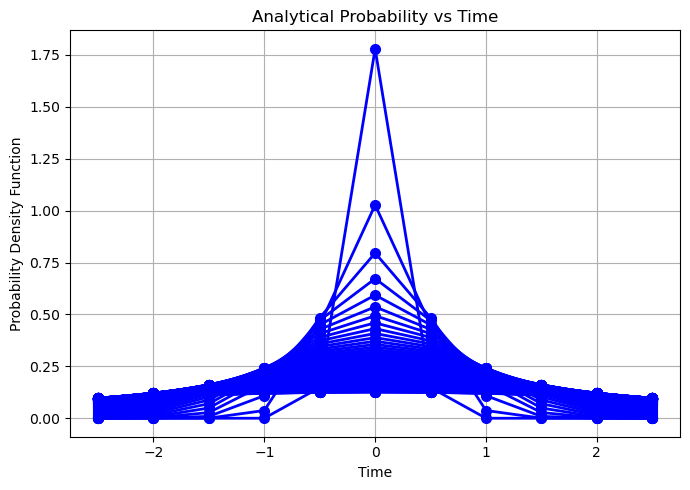

In [50]:
plt.figure(figsize=(7,5))
plt.plot(t_test,P_analytical,'bo-',linewidth=2,markersize=7,label='Analytical')
plt.xlabel("Time")
plt.ylabel("Probability Density Function")
plt.title("Analytical Probability vs Time")
plt.grid(True)
plt.tight_layout()
plt.show()

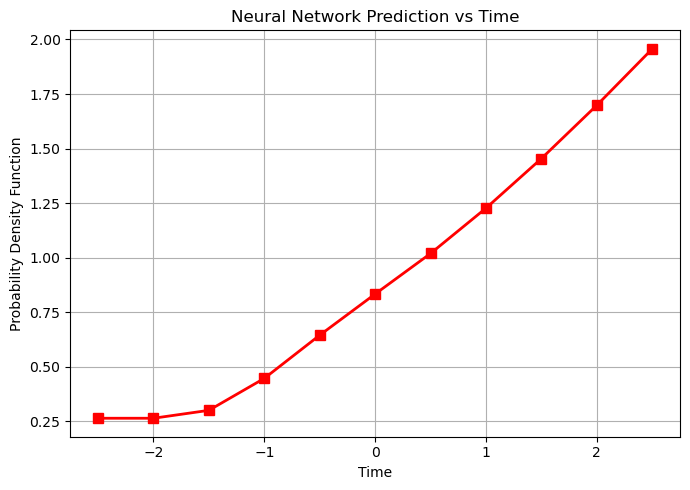

In [41]:
plt.figure(figsize=(7,5))
plt.plot(t_test,P,'rs-',linewidth=2,markersize=7)
plt.xlabel("Time")
plt.ylabel("Probability Density Function")
plt.title("Neural Network Prediction vs Time")
plt.grid(True)
plt.tight_layout()
plt.show()

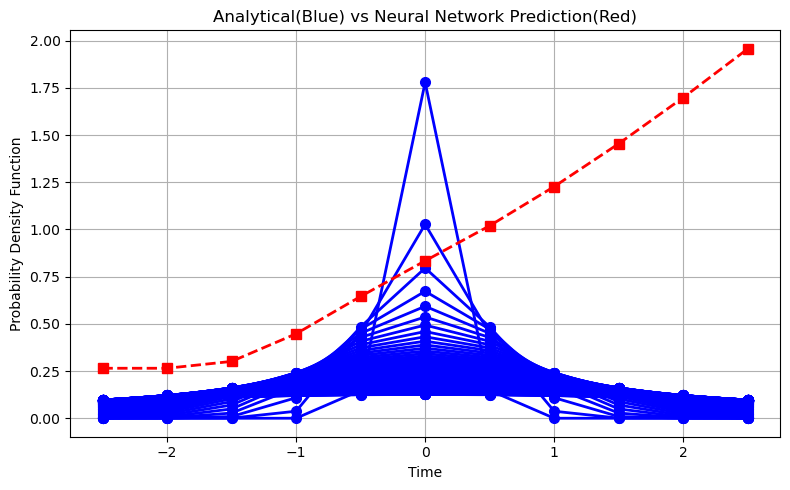

In [44]:
plt.figure(figsize=(8,5))
plt.plot(t_test,P_analytical, 'bo-',linewidth=2,markersize=7,label='Analytical')
plt.plot(t_test,P,'rs--',linewidth=2,markersize=7,label='Neural Network Prediction')
plt.xlabel("Time")
plt.ylabel("Probability Density Function")
plt.title("Analytical(Blue) vs Neural Network Prediction(Red)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
epochs=5000

print_at = [0, 500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500]

for epoch in range(epochs):
    T_loss=0
    for i in range(N):
        q0=np.array([[x_samples[i]],[t_samples[i]]]) #input vector for the current sample
        P_theo=(1/np.sqrt(4*np.pi*D*t_samples[i]))*np.exp(-x_samples[i]**2/(4*D*t_samples[i])) 
        # Forward pass
        Z1= np.dot(W1.T,q0)+b1
        q1=np.maximum(0,Z1) 
        Z2=np.dot(W2.T,q1)+b2
        P=np.log(1+np.exp(Z2)) # Prediction output
        
        # Loss calculation
        L=(1/2)*(P-P_theo)**2 # mean error square
        T_loss+=L
        # Backpropagation (computing derivatives)
        dL_dP= P-P_theo 
        dP_dZ2=(np.exp(Z2))/(1+np.exp(Z2)) #derivative of the prediction wrt pre-activation function
        delta2=dL_dP*dP_dZ2 #error term for layer 2
        dL_dW2=q1*delta2 #derivative of the loss wrt weight 2
        dL_db2=delta2 #derivative of the loss wrt bias 2
        
        dL_dq1=W2*delta2 #derivative of the loss wrt activation output of layer 1(ReLU)
        dL_dZ1=dL_dq1*(Z1>0) #derivative of the loss wrt pre-activation function of layer 1 (ReLU)
        delta1=dL_dZ1 #error term for layer 1
        dL_dW1=np.dot(q0,delta1.T) #derivative of the loss wrt weight 
        dL_db1=delta1 #derivative of the loss wrt to bias 1
        
        # Gradient descent update 
        W1=W1-lr*(dL_dW1) #updates weight 1
        W2=W2-lr*(dL_dW2) #updates weight 2 
        b1=b1-lr*delta1 #updates bias 1 
        b2=b2-lr*delta2 #updates bias 2 
    L_ave=T_loss/N
    if epoch in print_at:
        print(f"Epoch {epoch:4d} | Loss: {float(L_ave):.6f} | P: {float(P):.6f} | P_analytical: {float(P_theo):.6f}")    
        

C:\Users\Reneiloe Nyathela\AppData\Local\Temp\ipykernel_11048\2881394771.py:39: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"Epoch {epoch:4d} | Loss: {float(L_ave):.6f} | P: {float(P):.6f} | P_analytical: {float(P_theo):.6f}")


Epoch    0 | Loss: 0.000641 | P: 0.408519 | P_analytical: 0.426727
Epoch  500 | Loss: 0.000641 | P: 0.408518 | P_analytical: 0.426727
Epoch 1000 | Loss: 0.000641 | P: 0.408516 | P_analytical: 0.426727
Epoch 1500 | Loss: 0.000641 | P: 0.408514 | P_analytical: 0.426727
Epoch 2000 | Loss: 0.000641 | P: 0.408513 | P_analytical: 0.426727
Epoch 2500 | Loss: 0.000641 | P: 0.408511 | P_analytical: 0.426727
Epoch 3000 | Loss: 0.000641 | P: 0.408509 | P_analytical: 0.426727
Epoch 3500 | Loss: 0.000641 | P: 0.408508 | P_analytical: 0.426727
Epoch 4000 | Loss: 0.000641 | P: 0.408506 | P_analytical: 0.426727
Epoch 4500 | Loss: 0.000641 | P: 0.408504 | P_analytical: 0.426727


In [58]:
# Test points

x_newtest=np.array([50,50.5,51,51.5,52,52.5,53,53.5,54,54.5,55])
t_newtest=np.array([50,50.5,51,51.5,52,52.5,53,53.5,54,54.5,55])

print(f"{'x':>6} {'t':>6} {'P_analytical':>12} {'P':>12} {'Error':>12} {'% Error':>10}")
print("-" * 60)

for x_i, t_i in zip(x_newtest, t_newtest):

    # Analytical solution
    P_analytical=(1/np.sqrt(4*np.pi*D*t_i))*np.exp(-x_i**2/(4*D*t_i))

    # Network prediction
    q0=np.array([x_i, t_i])
    Z1=np.dot(W1.T, q0) + b1
    q1=np.maximum(0, Z1)
    Z2=np.dot(W2.T, q1) + b2
    P=np.log(1 + np.exp(Z2))

    error=abs(P - P_analytical)
    pct_error=(error/P_analytical)*100
    print(type(P), type(P_analytical), type(error)) 
    print(f"{x_i:>6.2f} {t_i:>6.2f} {P_analytical:>12.6f} {float(P[0][0]):>12.6f} {float(error[0][0]):>12.6f} {float(pct_error[0][0]):>9.2f}%")


    

     x      t P_analytical            P        Error    % Error
------------------------------------------------------------
<class 'numpy.ndarray'> <class 'numpy.float64'> <class 'numpy.ndarray'>
 50.00  50.00     0.000000    31.029836    31.029836 20871344775.10%
<class 'numpy.ndarray'> <class 'numpy.float64'> <class 'numpy.ndarray'>
 50.50  50.50     0.000000    31.337493    31.337493 24003949511.66%
<class 'numpy.ndarray'> <class 'numpy.float64'> <class 'numpy.ndarray'>
 51.00  51.00     0.000000    31.645150    31.645150 27602716687.26%
<class 'numpy.ndarray'> <class 'numpy.float64'> <class 'numpy.ndarray'>
 51.50  51.50     0.000000    31.952808    31.952808 31736499833.12%
<class 'numpy.ndarray'> <class 'numpy.float64'> <class 'numpy.ndarray'>
 52.00  52.00     0.000000    32.260465    32.260465 36484255916.99%
<class 'numpy.ndarray'> <class 'numpy.float64'> <class 'numpy.ndarray'>
 52.50  52.50     0.000000    32.568123    32.568123 41936519338.83%
<class 'numpy.ndarray'> <clas

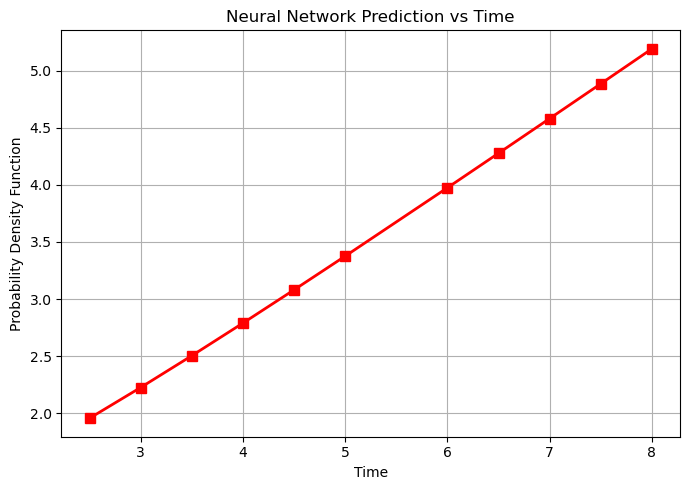

In [57]:
P=np.array([1.955025,2.224471,2.503076,2.788823,3.080061,3.375472,3.974946,4.277617,4.581593,4.886535,5.192792])
plt.figure(figsize=(7,5))
plt.plot(t_newtest,P,'rs-',linewidth=2,markersize=7)
plt.xlabel("Time")
plt.ylabel("Probability Density Function")
plt.title("Neural Network Prediction vs Time")
plt.grid(True)
plt.tight_layout()
plt.show()